# FIRELINE — DSA Integrated Baseline v2
## EDA, Feature Engineering, dan Low-Fidelity Dashboard untuk Checkpoint 1

Notebook ini menggabungkan:

1. Audit dan EDA yang mempertahankan seluruh **61.583 observasi** dataset utama.
2. Feature engineering pada unit **grid 0,1° × tanggal**.
3. Konteks sekolah dan batas provinsi sebagai dataset pendukung.
4. Skor **prioritas verifikasi provisional**, bukan skor risiko kebakaran.
5. Low-fidelity dashboard berbasis data untuk handoff PMA, UX, dan SEA.

### Keputusan produk

Pengguna utama adalah BPBD/command center/koordinator relawan. Produk membantu mengurutkan area yang perlu diverifikasi. Notebook ini tidak memprediksi kebakaran, tidak mengeluarkan status bahaya resmi, dan tidak merekomendasikan water bombing atau tindakan darurat otomatis.

In [1]:
from pathlib import Path
import json
import textwrap
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.neighbors import BallTree

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

def find_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv").exists():
            return candidate
    raise FileNotFoundError("Project root tidak ditemukan")

ROOT = find_root(Path.cwd().resolve())
CHECKPOINT_DIR = ROOT / "checkpoint_1"
OUTPUT_DIR = CHECKPOINT_DIR / "v2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIRMS_PATH = ROOT / "fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv"
SCHOOL_PATH = ROOT / "ujicoba" / "data" / "schools_indonesia" / "complete_data.csv"
PROVINCE_PATH = ROOT / "ujicoba" / "data" / "province_population" / "indonesia-province-jml-penduduk.json"

for path in [FIRMS_PATH, SCHOOL_PATH, PROVINCE_PATH]:
    assert path.exists(), f"File tidak ditemukan: {path}"

print("Project data located and validated.")
print("Output folder:", OUTPUT_DIR.name)

Project data located and validated.
Output folder: v2_outputs


## 1. Kontrak analisis dan guardrail

| Elemen | Kontrak |
|---|---|
| Unit data produk | Grid 0,1° per tanggal |
| Primary key | `(grid_id, date)` |
| Aksi pengguna | Memilih area untuk diverifikasi lebih dahulu |
| Target model | Tidak tersedia; tidak ada training model prediktif |
| Output | P1/P2/P3, alasan prioritas, dan catatan kualitas data |
| Confidence | Konteks kualitas observasi; tidak menjadi bobot skor |
| Sekolah | Proksi awal fasilitas sensitif; bukan bukti populasi terdampak |
| Provinsi | Filter/ringkasan dari boundary lama; bukan acuan administrasi final |

Kami tidak melakukan date-shifting data iklim, tidak membuang data menggunakan bounding box sempit, dan tidak mengubah FRP menjadi rekomendasi respons lapangan.

In [2]:
firms_raw = pd.read_csv(FIRMS_PATH)
schools_raw = pd.read_csv(SCHOOL_PATH)
provinces_raw = gpd.read_file(PROVINCE_PATH)

required_firms = {
    "latitude", "longitude", "brightness", "acq_date", "acq_time",
    "confidence", "bright_t31", "frp", "daynight", "type"
}
required_school = {"province_name", "school_name", "stage", "lat", "long"}
assert required_firms.issubset(firms_raw.columns)
assert required_school.issubset(schools_raw.columns)

dataset_audit = pd.DataFrame([
    {
        "dataset": "NASA FIRMS VIIRS NOAA-20",
        "status": "used",
        "rows": len(firms_raw),
        "purpose": "observasi anomali panas, waktu, FRP, dan kualitas observasi",
        "limitation": "observasi satelit bukan kejadian kebakaran terverifikasi",
    },
    {
        "dataset": "Indonesia School Dataset",
        "status": "used as provisional proxy",
        "rows": len(schools_raw),
        "purpose": "jarak fasilitas sensitif terdekat",
        "limitation": "snapshot/tahun tidak jelas dan tidak mewakili seluruh exposure",
    },
    {
        "dataset": "Indonesia Province GeoJSON",
        "status": "used with warning",
        "rows": len(provinces_raw),
        "purpose": "filter dan ringkasan wilayah",
        "limitation": "boundary lama; Kalimantan Utara belum terpisah secara andal",
    },
    {
        "dataset": "Historical climate / Pontianak weather",
        "status": "not used in scoring",
        "rows": np.nan,
        "purpose": "candidate for later research",
        "limitation": "periode dan cakupan spasial tidak selaras dengan data utama",
    },
])
display(dataset_audit)

firms_quality = pd.DataFrame({
    "column": firms_raw.columns,
    "dtype": [str(firms_raw[col].dtype) for col in firms_raw.columns],
    "missing_n": [int(firms_raw[col].isna().sum()) for col in firms_raw.columns],
    "unique_n": [int(firms_raw[col].nunique(dropna=True)) for col in firms_raw.columns],
})
display(firms_quality)

print(f"Raw rows              : {len(firms_raw):,}")
print(f"Exact duplicate rows  : {firms_raw.duplicated().sum():,}")
print(f"Total missing values  : {firms_raw.isna().sum().sum():,}")

,dataset,status,rows,purpose,limitation
0,NASA FIRMS VIIRS NOAA-20,used,61583.0,"observasi anomali panas, waktu, FRP, dan kuali...",observasi satelit bukan kejadian kebakaran ter...
1,Indonesia School Dataset,used as provisional proxy,215371.0,jarak fasilitas sensitif terdekat,snapshot/tahun tidak jelas dan tidak mewakili ...
2,Indonesia Province GeoJSON,used with warning,32.0,filter dan ringkasan wilayah,boundary lama; Kalimantan Utara belum terpisah...
3,Historical climate / Pontianak weather,not used in scoring,NaN,candidate for later research,periode dan cakupan spasial tidak selaras deng...


,column,dtype,missing_n,unique_n
0,latitude,float64,0,57283
1,longitude,float64,0,57874
2,brightness,float64,0,5462
3,scan,float64,0,49
4,track,float64,0,43
5,acq_date,object,0,629
6,acq_time,int64,0,279
7,satellite,object,0,1
8,instrument,object,0,1
9,confidence,object,0,3


Raw rows              : 61,583
Exact duplicate rows  : 0
Total missing values  : 0


## 2. Pembersihan minimal dan EDA yang aman

Semua baris dipertahankan selama tipe data, koordinat global, dan FRP valid. Pemeriksaan wilayah dilakukan sebagai **flag**, bukan alasan membuang ribuan observasi menggunakan bounding box sempit.

In [3]:
firms = firms_raw.copy()
firms["date"] = pd.to_datetime(firms["acq_date"], errors="coerce")
for col in ["latitude", "longitude", "frp", "brightness", "bright_t31"]:
    firms[col] = pd.to_numeric(firms[col], errors="coerce")
firms["confidence"] = firms["confidence"].astype(str).str.lower().str.strip()
firms["daynight"] = firms["daynight"].astype(str).str.upper().str.strip()

valid_mask = (
    firms["date"].notna()
    & firms["latitude"].between(-90, 90)
    & firms["longitude"].between(-180, 180)
    & firms["frp"].ge(0)
)
invalid_n = int((~valid_mask).sum())
firms = firms.loc[valid_mask].copy()

# Flag cakupan luas untuk sanity check; tidak dipakai untuk menghapus data.
firms["broad_kalimantan_extent_flag"] = (
    firms["latitude"].between(-5.5, 7.5)
    & firms["longitude"].between(108.0, 120.0)
)

daily = firms.groupby("date", as_index=False).agg(
    detection_count=("date", "size"),
    frp_median_mw=("frp", "median"),
    frp_p95_mw=("frp", lambda s: s.quantile(.95)),
)
daily["detections_7d"] = daily.set_index("date")["detection_count"].rolling("7D").sum().to_numpy()

year_summary = firms.groupby(firms["date"].dt.year).agg(
    detections=("date", "size"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    median_frp_mw=("frp", "median"),
).reset_index(names="year")
year_summary["coverage_note"] = np.select(
    [year_summary["year"].eq(2024), year_summary["year"].eq(2026)],
    ["partial: starts August", "partial: ends May"],
    default="full observed calendar year",
)

peak_day = daily.loc[daily["detection_count"].idxmax(), "date"]
peak_count = int(daily["detection_count"].max())

print(f"Invalid rows removed       : {invalid_n:,}")
print(f"Rows used                  : {len(firms):,}")
print(f"Broad extent flag = False  : {(~firms['broad_kalimantan_extent_flag']).sum():,}")
print(f"Date range                 : {firms['date'].min().date()} to {firms['date'].max().date()}")
print(f"Peak observed date         : {peak_day.date()} ({peak_count:,} observations)")
display(year_summary)

Invalid rows removed       : 0
Rows used                  : 61,583
Broad extent flag = False  : 0
Date range                 : 2024-08-01 to 2026-05-31
Peak observed date         : 2024-09-03 (2,400 observations)


,year,detections,first_date,last_date,median_frp_mw,coverage_note
0,2024,24884,2024-08-01,2024-12-31,6.410,partial: starts August
1,2025,29735,2025-01-01,2025-12-31,6.410,full observed calendar year
2,2026,6964,2026-01-02,2026-05-31,4.375,partial: ends May


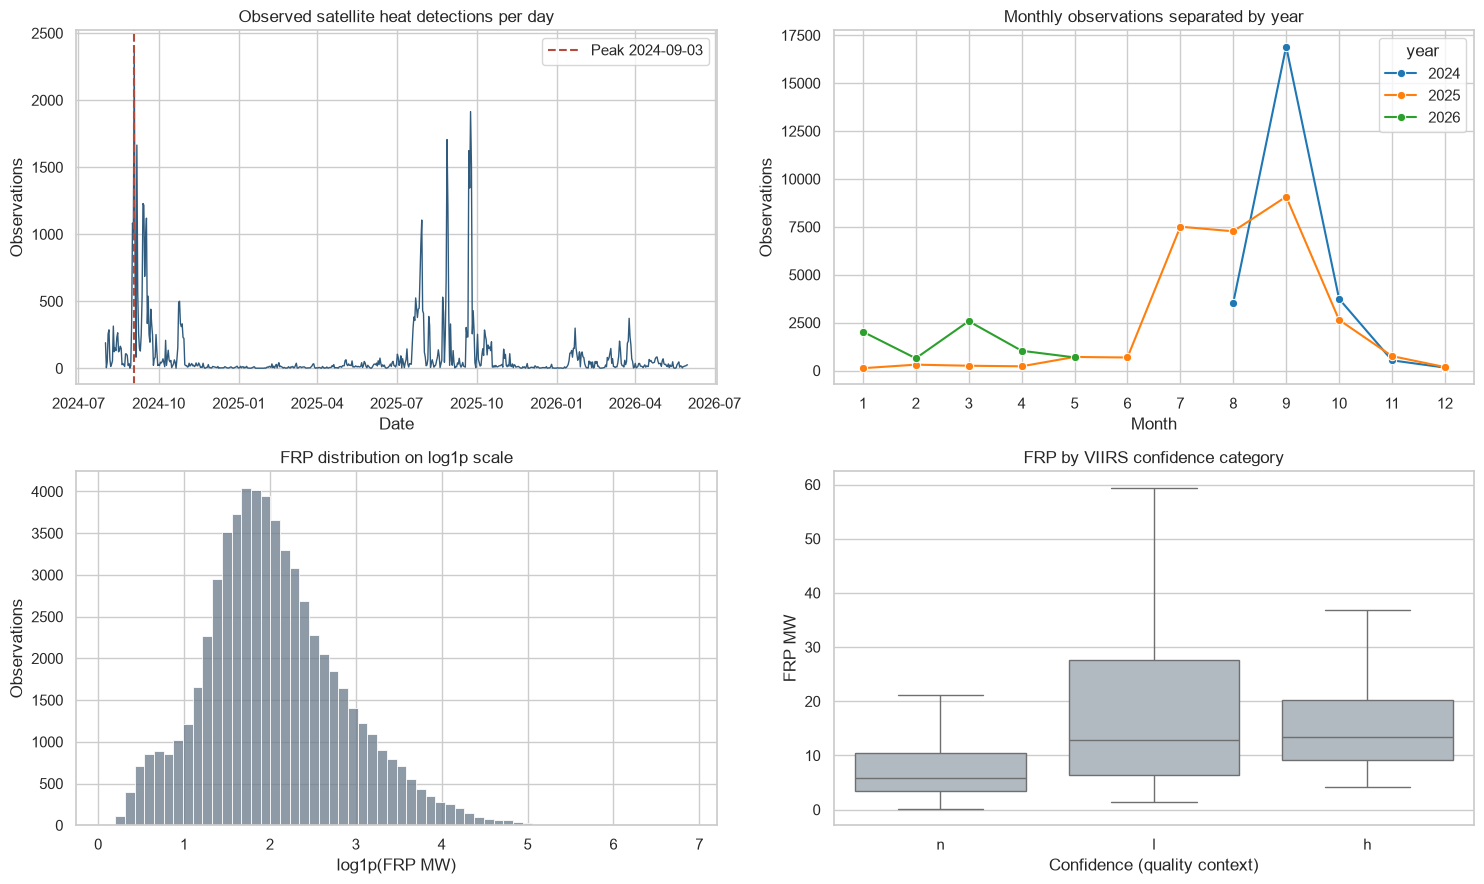

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(daily["date"], daily["detection_count"], color="#315b7d", linewidth=1)
axes[0, 0].axvline(peak_day, color="#b24c3d", linestyle="--", label=f"Peak {peak_day.date()}")
axes[0, 0].set(title="Observed satellite heat detections per day", xlabel="Date", ylabel="Observations")
axes[0, 0].legend()

month_year = firms.assign(year=firms["date"].dt.year, month=firms["date"].dt.month).groupby(["year", "month"]).size().reset_index(name="detections")
sns.lineplot(data=month_year, x="month", y="detections", hue="year", marker="o", ax=axes[0, 1], palette="tab10")
axes[0, 1].set(title="Monthly observations separated by year", xlabel="Month", ylabel="Observations", xticks=range(1, 13))

sns.histplot(np.log1p(firms["frp"]), bins=60, color="#697a89", ax=axes[1, 0])
axes[1, 0].set(title="FRP distribution on log1p scale", xlabel="log1p(FRP MW)", ylabel="Observations")

sns.boxplot(data=firms, x="confidence", y="frp", showfliers=False, color="#aebac4", ax=axes[1, 1])
axes[1, 1].set(title="FRP by VIIRS confidence category", xlabel="Confidence (quality context)", ylabel="FRP MW")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_overview_v2.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretasi EDA yang boleh dipakai

- Tahun 2024 dan 2026 parsial; total tahunan tidak boleh dibandingkan langsung dengan 2025.
- Jumlah observasi dan FRP mengukur dua hal berbeda.
- `confidence` menjelaskan konteks kualitas deteksi, bukan ukuran atau tingkat bahaya api.
- Deteksi malam tidak membuktikan kebakaran gambut.
- Area dengan observasi berulang adalah kandidat verifikasi/analisis lanjutan, bukan bukti lahan gambut atau kejadian kronis.

## 3. Feature engineering untuk kebutuhan dashboard

Observasi mentah diubah menjadi grid-tanggal agar satu baris mewakili satu unit yang dapat ditampilkan dan diurutkan pada dashboard.

In [5]:
GRID_DEG = 0.1
firms["lat_grid"] = (np.floor(firms["latitude"] / GRID_DEG) * GRID_DEG).round(1)
firms["lon_grid"] = (np.floor(firms["longitude"] / GRID_DEG) * GRID_DEG).round(1)
firms["grid_id"] = firms["lat_grid"].map(lambda x: f"{x:.1f}") + "_" + firms["lon_grid"].map(lambda x: f"{x:.1f}")
firms["is_high_conf"] = firms["confidence"].eq("h").astype(int)
firms["is_low_conf"] = firms["confidence"].eq("l").astype(int)
firms["is_nominal_or_high"] = firms["confidence"].isin(["n", "h"]).astype(int)
firms["is_night"] = firms["daynight"].eq("N").astype(int)

grid_date = firms.groupby(["grid_id", "lat_grid", "lon_grid", "date"], as_index=False).agg(
    detection_count=("grid_id", "size"),
    frp_median_mw=("frp", "median"),
    frp_max_mw=("frp", "max"),
    high_conf_share=("is_high_conf", "mean"),
    low_conf_share=("is_low_conf", "mean"),
    nominal_or_high_share=("is_nominal_or_high", "mean"),
    night_share=("is_night", "mean"),
)

def rolling_features(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("date").copy()
    indexed = group.set_index("date")
    group["detections_7d"] = indexed["detection_count"].rolling("7D").sum().to_numpy()
    group["active_days_7d"] = indexed["detection_count"].rolling("7D").count().to_numpy()
    return group

grid_date = grid_date.groupby("grid_id", group_keys=False).apply(rolling_features).reset_index(drop=True)
grid_date["grid_center_lat"] = grid_date["lat_grid"] + GRID_DEG / 2
grid_date["grid_center_lon"] = grid_date["lon_grid"] + GRID_DEG / 2

print(f"Unique grids   : {grid_date['grid_id'].nunique():,}")
print(f"Grid-date rows : {len(grid_date):,}")
assert not grid_date.duplicated(["grid_id", "date"]).any()
display(grid_date.head())

Unique grids   : 2,954
Grid-date rows : 27,411


,grid_id,lat_grid,lon_grid,date,detection_count,frp_median_mw,frp_max_mw,high_conf_share,low_conf_share,nominal_or_high_share,night_share,detections_7d,active_days_7d,grid_center_lat,grid_center_lon
0,-0.1_109.1,-0.1,109.1,2024-09-02,1,2.290,2.29,0.0,0.00,1.00,0.00,1.0,1.0,-0.05,109.15
1,-0.1_109.2,-0.1,109.2,2024-09-22,1,3.460,3.46,0.0,0.00,1.00,0.00,1.0,1.0,-0.05,109.25
2,-0.1_109.3,-0.1,109.3,2024-09-16,1,15.760,15.76,0.0,0.00,1.00,0.00,1.0,1.0,-0.05,109.35
3,-0.1_109.3,-0.1,109.3,2024-09-17,2,4.815,5.72,0.0,0.00,1.00,0.00,3.0,2.0,-0.05,109.35
4,-0.1_109.3,-0.1,109.3,2024-10-29,4,7.140,8.65,0.0,0.25,0.75,0.25,4.0,1.0,-0.05,109.35


## 4. Dataset pendukung: sekolah dan provinsi

Sekolah difilter menggunakan nama provinsi Kalimantan, bukan sekadar bounding box, agar sekolah dari pulau lain tidak ikut menjadi nearest neighbor. Label provinsi berasal dari boundary lama dan selalu disertai catatan kualitas.

In [6]:
schools = schools_raw.copy()
schools["lat"] = pd.to_numeric(schools["lat"], errors="coerce")
schools["long"] = pd.to_numeric(schools["long"], errors="coerce")
schools = schools[
    schools["province_name"].astype(str).str.contains("KALIMANTAN", case=False, na=False)
    & schools["lat"].between(-5.5, 7.5)
    & schools["long"].between(108.0, 120.0)
].dropna(subset=["lat", "long"]).copy()

grid_ref = grid_date[["grid_id", "grid_center_lat", "grid_center_lon"]].drop_duplicates().copy()
earth_radius_km = 6371.0088
tree = BallTree(np.radians(schools[["lat", "long"]].to_numpy()), metric="haversine")
dist_rad, school_idx = tree.query(np.radians(grid_ref[["grid_center_lat", "grid_center_lon"]].to_numpy()), k=1)
grid_ref["nearest_school_distance_km"] = dist_rad[:, 0] * earth_radius_km
nearest_school = schools.iloc[school_idx[:, 0]].reset_index(drop=True)
grid_ref["nearest_school_name"] = nearest_school["school_name"].to_numpy()
grid_ref["nearest_school_stage"] = nearest_school["stage"].to_numpy()

provinces = provinces_raw.to_crs(4326).copy()
provinces["geometry"] = provinces.geometry.make_valid()
kalimantan_boundaries = provinces[
    provinces["Propinsi"].astype(str).str.contains("KALIMANTAN", case=False, na=False)
].copy()

grid_points = gpd.GeoDataFrame(
    grid_ref,
    geometry=gpd.points_from_xy(grid_ref["grid_center_lon"], grid_ref["grid_center_lat"]),
    crs="EPSG:4326",
)
joined = gpd.sjoin(
    grid_points,
    kalimantan_boundaries[["Propinsi", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"], errors="ignore")
joined = joined.rename(columns={"Propinsi": "province_boundary_label"})
grid_ref = pd.DataFrame(joined.drop(columns="geometry"))

grid_date = grid_date.merge(grid_ref, on=["grid_id", "grid_center_lat", "grid_center_lon"], how="left")

print(f"Valid Kalimantan school coordinates : {len(schools):,}")
print(f"Median nearest-school distance      : {grid_ref['nearest_school_distance_km'].median():.2f} km")
print(f"Grids without province label        : {grid_ref['province_boundary_label'].isna().sum():,}")

Valid Kalimantan school coordinates : 17,364
Median nearest-school distance      : 3.61 km
Grids without province label        : 180


## 5. Prioritas verifikasi provisional

Formula transparan untuk prototipe:

`35% aktivitas hari ini + 30% persistensi 7 hari + 20% FRP median + 15% kedekatan sekolah`

Semua komponen memakai percentile rank. P1 adalah 10% skor tertinggi secara historis dan P2 adalah 20% berikutnya. Formula ini belum menjadi SOP; bobot dan threshold wajib divalidasi melalui mentoring serta user research.

In [7]:
score_weights = {
    "activity_score": 0.35,
    "persistence_score": 0.30,
    "intensity_score": 0.20,
    "exposure_score": 0.15,
}

grid_date["activity_score"] = grid_date["detection_count"].rank(pct=True, method="average")
grid_date["persistence_score"] = grid_date["detections_7d"].rank(pct=True, method="average")
grid_date["intensity_score"] = grid_date["frp_median_mw"].rank(pct=True, method="average")
grid_date["exposure_score"] = 1 - grid_date["nearest_school_distance_km"].rank(pct=True, method="average")
grid_date["priority_score"] = 100 * sum(grid_date[col] * weight for col, weight in score_weights.items())

p1_threshold = float(grid_date["priority_score"].quantile(.90))
p2_threshold = float(grid_date["priority_score"].quantile(.70))
grid_date["priority_level"] = np.select(
    [grid_date["priority_score"] >= p1_threshold, grid_date["priority_score"] >= p2_threshold],
    ["P1 - Verifikasi segera", "P2 - Pantau ketat"],
    default="P3 - Pemantauan biasa",
)

reason_labels = {
    "activity_score": "Aktivitas hari ini",
    "persistence_score": "Persistensi 7 hari",
    "intensity_score": "FRP relatif tinggi",
    "exposure_score": "Dekat sekolah",
}
score_columns = list(reason_labels)
grid_date["primary_reason"] = grid_date[score_columns].idxmax(axis=1).map(reason_labels)

grid_date["quality_status"] = np.select(
    [grid_date["province_boundary_label"].isna(), grid_date["low_conf_share"] >= .5],
    ["DATA TERBATAS: label provinsi tidak tersedia", "PERIKSA: proporsi low-confidence tinggi"],
    default="OK untuk eksplorasi",
)

level_order = pd.CategoricalDtype(
    ["P1 - Verifikasi segera", "P2 - Pantau ketat", "P3 - Pemantauan biasa"], ordered=True
)
grid_date["priority_level"] = grid_date["priority_level"].astype(level_order)

print(f"P1 threshold : {p1_threshold:.2f}")
print(f"P2 threshold : {p2_threshold:.2f}")
display(grid_date["priority_level"].value_counts().to_frame("grid_date_rows"))

P1 threshold : 77.77
P2 threshold : 62.04


,grid_date_rows
priority_level,
P3 - Pemantauan biasa,19187
P2 - Pantau ketat,5482
P1 - Verifikasi segera,2742


## 6. Low-fidelity dashboard dari DSA

Dashboard berikut adalah **wireframe berbasis data**, bukan UI final dan bukan live dashboard. Tujuannya adalah memberi UX struktur informasi dan memberi SEA kontrak field yang dibutuhkan.

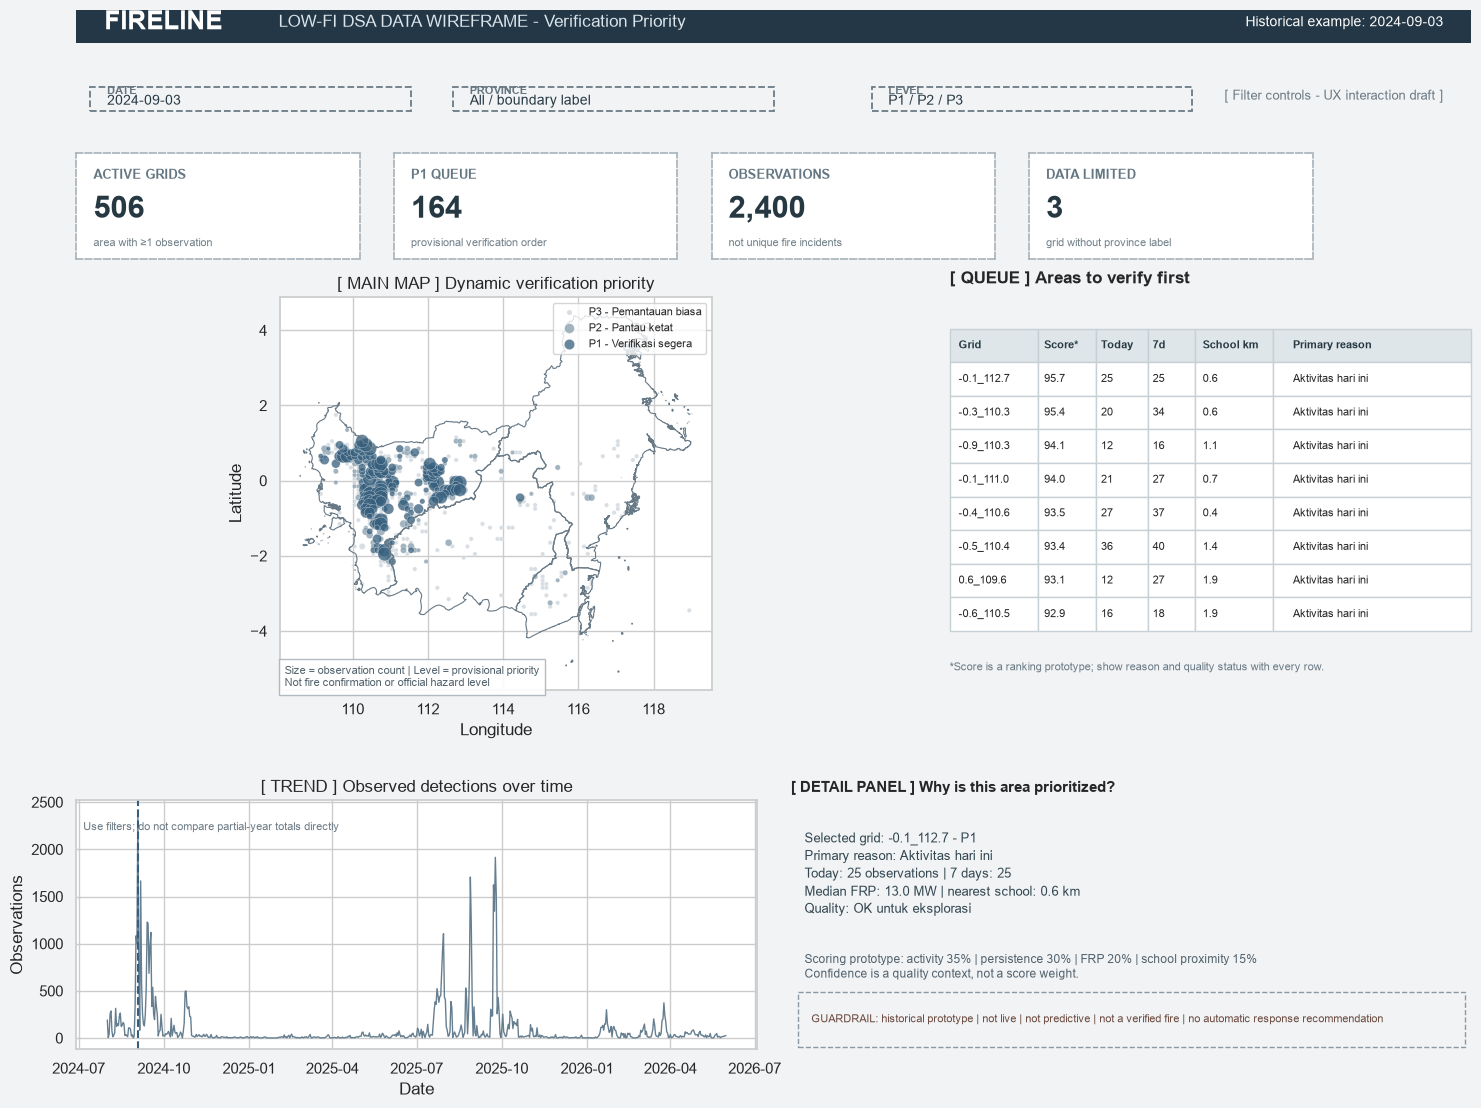

Low-fi wireframe saved: lowfi_dashboard_wireframe_v2.png


In [8]:
selected_date = peak_day
selected = grid_date[grid_date["date"].eq(selected_date)].copy()
queue = selected.sort_values(["priority_score", "detections_7d"], ascending=False).head(8).copy()

level_colors = {
    "P1 - Verifikasi segera": "#365f7d",
    "P2 - Pantau ketat": "#839bab",
    "P3 - Pemantauan biasa": "#cbd4da",
}

fig = plt.figure(figsize=(18, 13.5), facecolor="#f1f3f5")
gs = GridSpec(15, 18, figure=fig, hspace=1.15, wspace=0.75)

# Header
ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")
ax_header.add_patch(patches.Rectangle((0, 0), 1, 1, transform=ax_header.transAxes, color="#243746"))
ax_header.text(.02, .62, "FIRELINE", color="white", fontsize=19, weight="bold", va="center")
ax_header.text(.145, .62, "LOW-FI DSA DATA WIREFRAME - Verification Priority", color="#dce5eb", fontsize=12, va="center")
ax_header.text(.98, .62, f"Historical example: {selected_date.date()}", color="white", fontsize=10, ha="right", va="center")

# Filters
ax_filters = fig.add_subplot(gs[1, :])
ax_filters.axis("off")
for x, label, value in [(.01, "DATE", str(selected_date.date())), (.27, "PROVINCE", "All / boundary label"), (.57, "LEVEL", "P1 / P2 / P3")]:
    ax_filters.add_patch(patches.Rectangle((x, .12), .23, .72, transform=ax_filters.transAxes, fill=False, linestyle="--", linewidth=1.3, edgecolor="#6c7b86"))
    ax_filters.text(x+.012, .63, label, fontsize=8, color="#667680", weight="bold")
    ax_filters.text(x+.012, .31, value, fontsize=10, color="#263943")
ax_filters.text(.98, .46, "[ Filter controls - UX interaction draft ]", fontsize=9, color="#6c7b86", ha="right")

# KPI cards
kpi_values = [
    ("ACTIVE GRIDS", f"{selected['grid_id'].nunique():,}", "area with ≥1 observation"),
    ("P1 QUEUE", f"{(selected['priority_level'] == 'P1 - Verifikasi segera').sum():,}", "provisional verification order"),
    ("OBSERVATIONS", f"{selected['detection_count'].sum():,}", "not unique fire incidents"),
    ("DATA LIMITED", f"{selected['province_boundary_label'].isna().sum():,}", "grid without province label"),
]
for i, (label, value, note) in enumerate(kpi_values):
    ax = fig.add_subplot(gs[2:4, i*4:(i+1)*4])
    ax.set_facecolor("white")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("#aab5bc"); spine.set_linestyle("--")
    ax.text(.06, .76, label, transform=ax.transAxes, fontsize=9, color="#647681", weight="bold")
    ax.text(.06, .39, value, transform=ax.transAxes, fontsize=22, color="#263943", weight="bold")
    ax.text(.06, .12, note, transform=ax.transAxes, fontsize=8, color="#72818a")

# Map
ax_map = fig.add_subplot(gs[4:10, :11])
ax_map.set_facecolor("white")
kalimantan_boundaries.boundary.plot(ax=ax_map, color="#687986", linewidth=.8)
for level in level_order.categories[::-1]:
    subset = selected[selected["priority_level"].eq(level)]
    ax_map.scatter(
        subset["grid_center_lon"], subset["grid_center_lat"],
        s=np.clip(subset["detection_count"] * 5, 10, 100),
        color=level_colors[level], alpha=.75, label=level,
        edgecolor="white", linewidth=.25,
    )
ax_map.set(title="[ MAIN MAP ] Dynamic verification priority", xlabel="Longitude", ylabel="Latitude")
ax_map.legend(loc="upper right", fontsize=8, frameon=True)
ax_map.text(.01, .01, "Size = observation count | Level = provisional priority\nNot fire confirmation or official hazard level", transform=ax_map.transAxes, fontsize=8, color="#52626d", bbox=dict(facecolor="white", edgecolor="#aab5bc", alpha=.9))

# Queue
ax_queue = fig.add_subplot(gs[4:10, 11:])
ax_queue.axis("off")
ax_queue.set_title("[ QUEUE ] Areas to verify first", loc="left", fontsize=12, weight="bold", pad=10)
queue_display = queue[["grid_id", "priority_score", "detection_count", "detections_7d", "nearest_school_distance_km", "primary_reason"]].copy()
queue_display.columns = ["Grid", "Score*", "Today", "7d", "School km", "Primary reason"]
queue_display["Score*"] = queue_display["Score*"].round(1)
queue_display["7d"] = queue_display["7d"].astype(int)
queue_display["School km"] = queue_display["School km"].round(1)
table = ax_queue.table(cellText=queue_display.values, colLabels=queue_display.columns, cellLoc="left", colLoc="left", loc="upper left", bbox=[0, .15, 1, .77], colWidths=[.17,.11,.10,.09,.15,.38])
table.auto_set_font_size(False); table.set_fontsize(7.7)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#c7d0d5")
    if row == 0:
        cell.set_facecolor("#dfe6ea"); cell.set_text_props(weight="bold", color="#263943")
    else:
        cell.set_facecolor("white")
ax_queue.text(0, .05, "*Score is a ranking prototype; show reason and quality status with every row.", fontsize=8, color="#6c7b86", transform=ax_queue.transAxes)

# Bottom trend
ax_trend = fig.add_subplot(gs[11:, :9])
ax_trend.plot(daily["date"], daily["detection_count"], color="#667f90", linewidth=1)
ax_trend.axvline(selected_date, color="#365f7d", linestyle="--")
ax_trend.set(title="[ TREND ] Observed detections over time", xlabel="Date", ylabel="Observations")
ax_trend.text(.01, .88, "Use filters; do not compare partial-year totals directly", transform=ax_trend.transAxes, fontsize=8, color="#6c7b86")

# Bottom explanation
ax_explain = fig.add_subplot(gs[11:, 9:])
ax_explain.axis("off")
ax_explain.set_title("[ DETAIL PANEL ] Why is this area prioritized?", loc="left", fontsize=11, weight="bold")
top = queue.iloc[0]
explain_lines = [
    f"Selected grid: {top['grid_id']} - P1",
    f"Primary reason: {top['primary_reason']}",
    f"Today: {int(top['detection_count'])} observations | 7 days: {int(top['detections_7d'])}",
    f"Median FRP: {top['frp_median_mw']:.1f} MW | nearest school: {top['nearest_school_distance_km']:.1f} km",
    f"Quality: {top['quality_status']}",
]
ax_explain.text(.02, .88, "\n".join(explain_lines), va="top", fontsize=9, color="#334751", linespacing=1.5)
ax_explain.text(.02, .39, "Scoring prototype: activity 35% | persistence 30% | FRP 20% | school proximity 15%\nConfidence is a quality context, not a score weight.", va="top", fontsize=8.3, color="#52626d", linespacing=1.35)
ax_explain.add_patch(patches.Rectangle((.01, .01), .98, .22, transform=ax_explain.transAxes, fill=False, linestyle="--", edgecolor="#8b99a2"))
ax_explain.text(.03, .12, "GUARDRAIL: historical prototype | not live | not predictive | not a verified fire | no automatic response recommendation", transform=ax_explain.transAxes, fontsize=7.7, color="#6d4c41", va="center", wrap=True)

fig.suptitle("", y=.99)
wireframe_path = OUTPUT_DIR / "lowfi_dashboard_wireframe_v2.png"
plt.savefig(wireframe_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Low-fi wireframe saved:", wireframe_path.name)

## 7. Ekspor kontrak data untuk PMA, UX, dan SEA

- PMA memakai temuan, scope, dan batasan.
- UX memakai wireframe, contoh queue, label, dan state kualitas.
- SEA memakai primary key, schema, filter, dan komponen skor.
- DSA memakai notebook sebagai baseline reproducible untuk iterasi berikutnya.

In [9]:
export_columns = [
    "grid_id", "date", "grid_center_lat", "grid_center_lon", "province_boundary_label",
    "detection_count", "detections_7d", "active_days_7d", "frp_median_mw", "frp_max_mw",
    "high_conf_share", "low_conf_share", "nominal_or_high_share", "night_share",
    "nearest_school_distance_km", "nearest_school_name", "nearest_school_stage",
    "activity_score", "persistence_score", "intensity_score", "exposure_score",
    "priority_score", "priority_level", "primary_reason", "quality_status",
]
dashboard_data = grid_date[export_columns].copy()
dashboard_data["date"] = dashboard_data["date"].dt.strftime("%Y-%m-%d")

feature_dictionary = pd.DataFrame([
    ["grid_id", "string", "Grid 0.1 degree identifier", "dashboard/API key"],
    ["date", "date", "Observation aggregation date", "time filter/API key"],
    ["detection_count", "integer", "Satellite observations in grid-date", "KPI/queue"],
    ["detections_7d", "integer", "Observations in trailing 7 days", "persistence context"],
    ["active_days_7d", "integer", "Active observed days in trailing 7 days", "persistence context"],
    ["frp_median_mw", "float", "Median pixel-integrated FRP", "intensity context"],
    ["low_conf_share", "float 0-1", "Share of low-confidence observations", "quality context only"],
    ["night_share", "float 0-1", "Share of night observations", "observation context only"],
    ["nearest_school_distance_km", "float km", "Nearest school distance from grid center", "provisional facility context"],
    ["priority_score", "float 0-100", "Provisional verification ranking", "queue order; not official risk"],
    ["priority_level", "category", "P1/P2/P3 prototype level", "map/queue label"],
    ["primary_reason", "string", "Largest score component", "explainability"],
    ["quality_status", "string", "Boundary/confidence warning", "data-limited UI state"],
], columns=["field", "type_unit", "definition", "consumer"])

dashboard_contract = {
    "name": "FIRELINE Dynamic Verification Priority — Checkpoint 1",
    "status": "historical low-fi prototype",
    "unit_of_analysis": "0.1 degree grid x date",
    "primary_key": ["grid_id", "date"],
    "filters": ["date", "province_boundary_label", "priority_level"],
    "score_status": "provisional; requires stakeholder validation",
    "score_weights": score_weights,
    "score_thresholds": {"P1_min": p1_threshold, "P2_min": p2_threshold},
    "forbidden_claims": [
        "verified fire",
        "official hazard level",
        "predictive early warning",
        "peat fire based on nighttime observation alone",
        "automatic water-bombing recommendation",
    ],
    "recommended_ui_states": ["P1", "P2", "P3", "DATA TERBATAS"],
}

dataset_audit.to_csv(OUTPUT_DIR / "dataset_audit_v2.csv", index=False)
firms_quality.to_csv(OUTPUT_DIR / "firms_quality_v2.csv", index=False)
year_summary.to_csv(OUTPUT_DIR / "year_coverage_v2.csv", index=False)
dashboard_data.to_csv(OUTPUT_DIR / "dashboard_grid_date_v2.csv", index=False)
queue_display.to_csv(OUTPUT_DIR / "dashboard_queue_sample_v2.csv", index=False)
feature_dictionary.to_csv(OUTPUT_DIR / "feature_dictionary_v2.csv", index=False)
with open(OUTPUT_DIR / "dashboard_contract_v2.json", "w", encoding="utf-8") as fh:
    json.dump(dashboard_contract, fh, indent=2, ensure_ascii=False)

methodology = f'''# FIRELINE DSA Baseline v2 — Methodology Summary

## Output decision

Checkpoint 1 uses a data-informed low-fidelity dashboard exported from Python. It is not a live BI dashboard.

## Verified data facts

- Raw observations: {len(firms_raw):,}
- Used observations after minimal validity checks: {len(firms):,}
- Date range: {firms['date'].min().date()} to {firms['date'].max().date()}
- Unique 0.1-degree grids: {grid_date['grid_id'].nunique():,}
- Grid-date rows: {len(grid_date):,}
- Historical peak: {peak_day.date()} with {peak_count:,} observations
- Grids without province boundary label: {grid_ref['province_boundary_label'].isna().sum():,}

## Feature engineering

Activity, trailing-seven-day persistence, FRP summary, nearest-school distance, province boundary label, confidence/day-night context, provisional priority score, reason, and quality status.

## Guardrails

No date-shifted climate correlation, predictive model, official risk category, peat-fire inference from night observation alone, or automatic response recommendation is included.
'''
(OUTPUT_DIR / "methodology_summary_v2.md").write_text(methodology, encoding="utf-8")

print("Exported files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {path.name}: {path.stat().st_size / 1024:.1f} KB")

Exported files:
- dashboard_contract_v2.json: 0.9 KB
- dashboard_grid_date_v2.csv: 7975.4 KB
- dashboard_queue_sample_v2.csv: 0.4 KB
- dataset_audit_v2.csv: 0.6 KB
- eda_overview_v2.png: 244.8 KB
- feature_dictionary_v2.csv: 1.0 KB
- firms_quality_v2.csv: 0.4 KB
- lowfi_dashboard_wireframe_v2.png: 499.9 KB
- methodology_summary_v2.md: 0.9 KB
- year_coverage_v2.csv: 0.2 KB


## 8. Kesimpulan untuk Checkpoint 1

Output yang digunakan adalah **data-informed low-fidelity dashboard** dari notebook ini. Hasilnya cukup untuk memperlihatkan rancangan dashboard dan progres feature engineering. UX dapat memindahkan komponen ke Figma, sedangkan SEA dapat memakai schema CSV/JSON sebagai dasar API atau frontend pada checkpoint berikutnya.

Hal yang harus divalidasi pada mentoring:

1. Apakah grid 0,1° mudah dipahami operator?
2. Apakah empat komponen prioritas sesuai cara kerja lapangan?
3. Apakah istilah P1/P2/P3 dipahami dan tidak disangka status bahaya resmi?
4. Apakah sekolah layak dipertahankan sebagai konteks sementara?
5. Apa tindakan manusia setelah sebuah area masuk P1?